In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense

df = pd.read_csv('creditcard.csv')

print("5 Baris Pertama Dataset :")
print(df.head())

# Mengecek data kosong
print("\nJumlah Data Kosong di setiap kolom :")
print(df.isnull().sum())

5 Baris Pertama Dataset :
   Time  Profiling Nasabah Gen-1  Profiling Nasabah Gen-2  \
0   0.0                -1.359807                -0.072781   
1   0.0                 1.191857                 0.266151   
2   1.0                -1.358354                -1.340163   
3   1.0                -0.966272                -0.185226   
4   2.0                -1.158233                 0.877737   

   Profiling Nasabah Gen-3  Pola Jejak Digital B  Profiling Nasabah Gen-4  \
0                 2.536347              1.378155                -0.338321   
1                 0.166480              0.448154                 0.060018   
2                 1.773209              0.379780                -0.503198   
3                 1.792993             -0.863291                -0.010309   
4                 1.548718              0.403034                -0.407193   

   Profiling Nasabah Gen-5  Validasi Otentikasi A  Profiling Nasabah Gen-6  \
0                 0.462388               0.239599                 

In [6]:
X = df.drop('Class', axis=1)
y = df['Class']

# Split data (80% latih, 20% uji)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nJumlah nasabah untuk di latih : {len(X_train)}")
print(f"Jumlah nasabah untuk di uji   : {len(X_test)}")

# Feature Scaling (Sangat penting karena ada kolom 'Time' dan 'Amount' yang angkanya besar)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nContoh data pasien setelah scaling (fokus pada fitur pertama):")
print(X_train_scaled[0])


Jumlah nasabah untuk di latih : 227845
Jumlah nasabah untuk di uji   : 56962

Contoh data pasien setelah scaling (fokus pada fitur pertama):
[ 1.02255459  0.99785119 -0.22962626 -0.20738468  0.23421529 -0.36779128
 -0.0640219  -0.50588871  0.03060393  0.95995457 -0.02686352  0.61149957
  1.68999033  1.26149805 -0.26397318 -0.36292946  0.34942719 -1.09376318
  0.77802759  0.20615616 -0.1625072   0.32483903  1.3366986   0.08456891
 -0.45980186 -0.08436785 -0.44894226  0.11248883 -0.14374055 -0.30788875]


In [7]:
model = Sequential([
    # Input layer otomatis menyesuaikan jumlah kolom di X
    Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    # Output layer 1 neuron dengan Sigmoid untuk klasifikasi 0 atau 1
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Menampilkan Summary Model
model.summary()

c:\Users\Dwikrwn\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model = Sequential([
    # Layer 1: Dense dengan 16 neuron (berdasarkan param 256)
    Dense(16, activation='relu', input_dim=X_train.shape[1], name="dense"),
    # Layer 2: Output dengan 1 neuron (berdasarkan param 17)
    Dense(1, activation='sigmoid', name="dense_1")
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Tampilkan Summary Model
model.summary()

# Menggunakan 50 Epochs
print("\nMemulai Training...")
history = model.fit(X_train_scaled, y_train, 
                    epochs=5, 
                    batch_size=32, 
                    validation_data=(X_test_scaled, y_test),
                    verbose=1)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)


Memulai Training...
Epoch 1/5
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - accuracy: 0.9957 - loss: 0.0202 - val_accuracy: 0.9993 - val_loss: 0.0039
Epoch 2/5
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.9993 - loss: 0.0034 - val_accuracy: 0.9992 - val_loss: 0.0035
Epoch 3/5
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.9994 - loss: 0.0031 - val_accuracy: 0.9994 - val_loss: 0.0031
Epoch 4/5
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.9995 - loss: 0.0028 - val_accuracy: 0.9994 - val_loss: 0.0031
Epoch 5/5
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.9995 - loss: 0.0027 - val_accuracy: 0.9994 - val_loss: 0.0032


In [9]:
# 6. AKURASI AKHIR
print("\n" + "="*50)
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Akursi model : {accuracy*100:.2f}%")


Akursi model : 99.94%


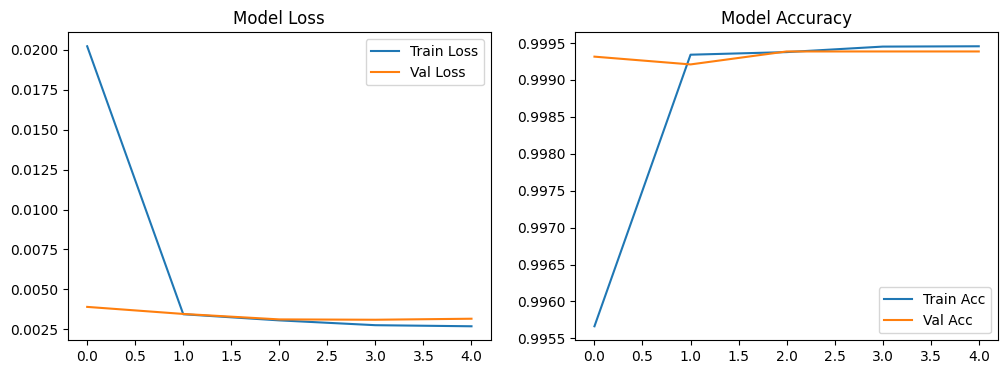

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9983 - loss: 253.5907

Akurasi pada data uji: 99.83%


In [10]:
# EVALUASI DAN VISUALISASI
plt.figure(figsize=(12, 4))

# Grafik Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

# Grafik Akurasi
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.legend()

plt.show()

# Print akurasi akhir
loss, acc = model.evaluate(X_test, y_test)
print(f"\nAkurasi pada data uji: {acc*100:.2f}%")